In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [17]:
df.isna().sum()

,0
id,0
health_condition,0
sleep_duration,75999
heart_rate,7833
bmi,13898
calorie_expenditure,52853
step_count,13916
exercise_duration,6901
water_intake,43477
diet_type,6901


In [20]:
x = df.drop(['id', 'health_condition'], axis = 1)
y = df['health_condition']

In [26]:
for col in x.columns:
  print(col, x[col].dtype)
  if (x[col].dtype == "object"): print(x[col].unique())
  print()

sleep_duration float64

heart_rate float64

bmi float64

calorie_expenditure float64

step_count float64

exercise_duration float64

water_intake float64

diet_type object
['veg' 'non-veg' 'balanced' nan]

stress_level object
['high' 'low' nan 'medium']

sleep_quality object
['average' 'poor' nan 'good']

physical_activity_level object
['sedentary' 'moderate' 'active' nan]

smoking_alcohol object
['yes' 'occasional' nan 'no']

gender object
['female' 'other' 'male' nan]



In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [28]:
# Numeric Columns
numeric_cols = [
    'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
    'step_count', 'exercise_duration', 'water_intake'
]

# Object Columns - Nominal (No ranked order -> One-Hot Encode)
nominal_cols = [
    'diet_type', 'gender'
]

# Object Columns - Ordinal (Ranked order -> Ordinal Encode)
ordinal_cols = [
    'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol'
]

In [29]:
stress_categories = ['low', 'medium', 'high']
sleep_categories = ['poor', 'average', 'good']
activity_categories = ['sedentary', 'moderate', 'active']
smoking_categories = ['no', 'occasional', 'yes']

In [31]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[stress_categories, sleep_categories, activity_categories, smoking_categories],
                               handle_unknown="use_encoded_value",
                               unknown_value=-1))
])

In [32]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('ord', ordinal_transformer, ordinal_cols)
])

In [33]:
x = preprocessor.fit_transform(x)

In [35]:
x.shape

(690088, 17)

In [116]:
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.models import Model

In [115]:
def build_model(T):
  i = Input(shape=(T,))
  x = Dense(128, activation='relu')(i)
  x = BatchNormalization()(x)
  x = Dropout(0.2)(x)
  x = Dense(64, activation='relu')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.2)(x)
  x = Dense(32, activation='relu')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.2)(x)
  x = Dense(16, activation='relu')(x)
  x = BatchNormalization()(x)
  x = Dropout(0.2)(x)
  x = Dense(3, activation='softmax')(x)

  model = Model(i, x)
  return model

In [117]:
model = build_model(x.shape[1])

In [54]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [40]:
y.unique()

array(['unhealthy', 'at-risk', 'fit'], dtype=object)

In [44]:
y = y.map({"unhealthy":0, "at-risk":1, "fit":2})

In [55]:
early_stopper = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [56]:
model.fit(x, y, batch_size=32, epochs=200, validation_split=0.2, callbacks=[early_stopper])

Epoch 1/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 80s 4ms/step - accuracy: 0.9380 - loss: 0.2109 - val_accuracy: 0.9619 - val_loss: 0.1402
Epoch 2/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 64s 4ms/step - accuracy: 0.9580 - loss: 0.1606 - val_accuracy: 0.9619 - val_loss: 0.1320
Epoch 3/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 64s 4ms/step - accuracy: 0.9592 - loss: 0.1524 - val_accuracy: 0.9634 - val_loss: 0.1267
Epoch 4/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 64s 4ms/step - accuracy: 0.9597 - loss: 0.1490 - val_accuracy: 0.9626 - val_loss: 0.1270
Epoch 5/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.9599 - loss: 0.1464 - val_accuracy: 0.9632 - val_loss: 0.1254
Epoch 6/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 63s 4ms/step - accuracy: 0.9601 - loss: 0.1454 - val_accuracy: 0.9626 - val_loss: 0.1256
Epoch 7/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 64s 4ms/step - accuracy: 0.9603 - loss: 0.1444 - val_accuracy: 0.9636 - val_loss: 0.1234
Epoch 8/200
17253/17253 ━━━━━━━━━━━━━━━━━━━━ 64s 4ms/step - ac

In [58]:
r = model.history

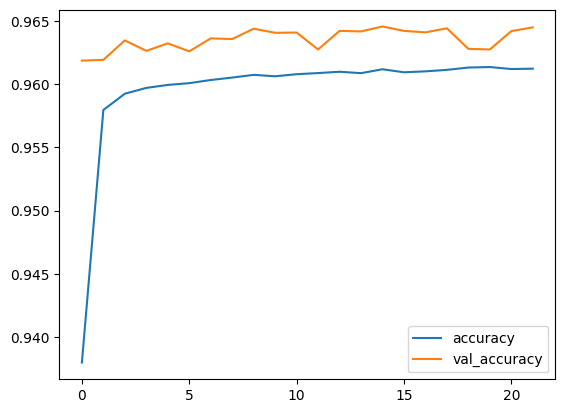

In [62]:
# plot accuracy and loss graphs
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()

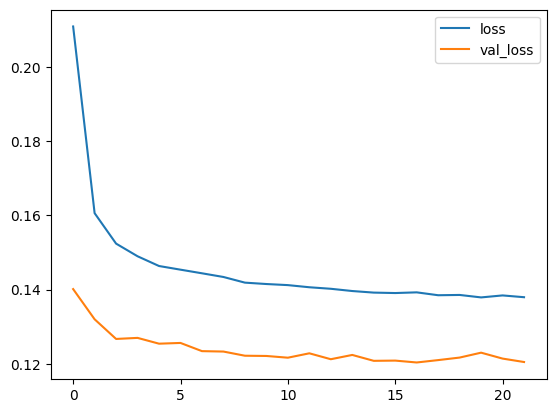

In [63]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

In [99]:
test_df = pd.read_csv("/content/test.csv")

In [83]:
test_df.isna().sum()

,0
id,0
sleep_duration,32571
heart_rate,3357
bmi,5956
calorie_expenditure,22652
step_count,5964
exercise_duration,2958
water_intake,18633
diet_type,2958
stress_level,35490


In [84]:
id = test_df.id

In [85]:
id

,id
0,690088
1,690089
2,690090
3,690091
4,690092
...,...
295748,985836
295749,985837
295750,985838
295751,985839


In [100]:
test_df.drop('id', axis = 1, inplace=True)

In [68]:
test_df = preprocessor.transform(test_df)

In [69]:
test_df

array([[-1.43242095e+00, -1.25440788e+00,  2.01481423e-01, ...,
         0.00000000e+00,  2.00000000e+00,  1.00000000e+00],
       [-2.01588594e-03,  9.84607956e-01, -2.29997504e-01, ...,
         0.00000000e+00,  0.00000000e+00,  2.00000000e+00],
       [-2.72397330e-01, -1.89412669e+00,  4.70138114e-01, ...,
         0.00000000e+00,  2.00000000e+00,  0.00000000e+00],
       ...,
       [-2.01588594e-03,  2.34168583e-01,  2.58469206e-01, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.24755648e-01, -1.08217589e+00, -6.16700317e-01, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-2.07784762e+00,  1.23065365e+00,  3.27668657e-01, ...,
         1.00000000e+00,  2.00000000e+00,  1.00000000e+00]])

In [103]:
y_hat = model.predict(test_df)

9243/9243 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step


In [104]:
y_hat = np.argmax(y_hat, axis=1)

In [105]:
label_mapping = np.array(['unhealthy', 'at-risk', 'fit'])
predictions = label_mapping[y_hat]

In [80]:
predictions.shape

(295753,)

In [81]:
test_df.shape

(295753, 17)

In [106]:
# 1. Combine your IDs and Predictions into a DataFrame
submission = pd.DataFrame({
    'id': id,
    'health_condition': predictions
})

# 2. Export to a CSV file
submission.to_csv('submission.csv', index=False)

In [90]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200)

In [92]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [93]:
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200)

In [94]:
from sklearn.metrics import accuracy_score
y_pred = rfc.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9648451651233897


In [97]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Initialize the model
# n_jobs=-1 is CRITICAL in Colab. It forces Colab to use both CPU cores,
# which might actually drop your base fit time from 5 minutes to ~3 minutes!
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Define a broader grid (We can make this big because we won't test them all)
param_dist = {
    # Keep estimators at or below your baseline to prevent 10-minute fits
    'n_estimators': [50, 80, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Setup Randomized Search for a STRICT time budget
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,          # ONLY try 3 random combinations
    cv=2,              # ONLY do 2-fold cross-validation
    scoring='accuracy',
    random_state=42,   # Keeps the random selection consistent if you re-run
    verbose=3          # Set to 3 so Colab prints out the time each fit takes!
)

# TOTAL FITS = n_iter (3) * cv (2) = 6 total fits.
# At 5 minutes each, this will take exactly ~30 minutes.

# 4. Run it
print("Starting Randomized Search (Budget: 6 fits, ~30 mins)...")
random_search.fit(x_train, y_train)

# 5. Extract results
print("\n--- Search Completed ---")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")

best_rf_model = random_search.best_estimator_

Starting Randomized Search (Budget: 6 fits, ~30 mins)...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV 1/2] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50;, score=0.964 total time=  21.7s
[CV 2/2] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50;, score=0.964 total time=  16.2s
[CV 1/2] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.965 total time=  29.1s
[CV 2/2] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.965 total time=  30.2s
[CV 1/2] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_estimators=80;, score=0.965 total time=  45.4s
[CV 2/2] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_estimators=80;, score=0.965 total time=  44.1s

--- Search Completed ---
Best Parameters: {'n_estimators': 80, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}
Best CV Score: 0.9648


In [102]:
test_df = preprocessor.fit_transform(test_df)